In [1]:
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.image import resize
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
SEED = 42
BATCH_SIZE = 64
NUM_CLASSES = 10
TARGET = 96

np.random.seed(SEED)
tf.random.set_seed(SEED)



170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


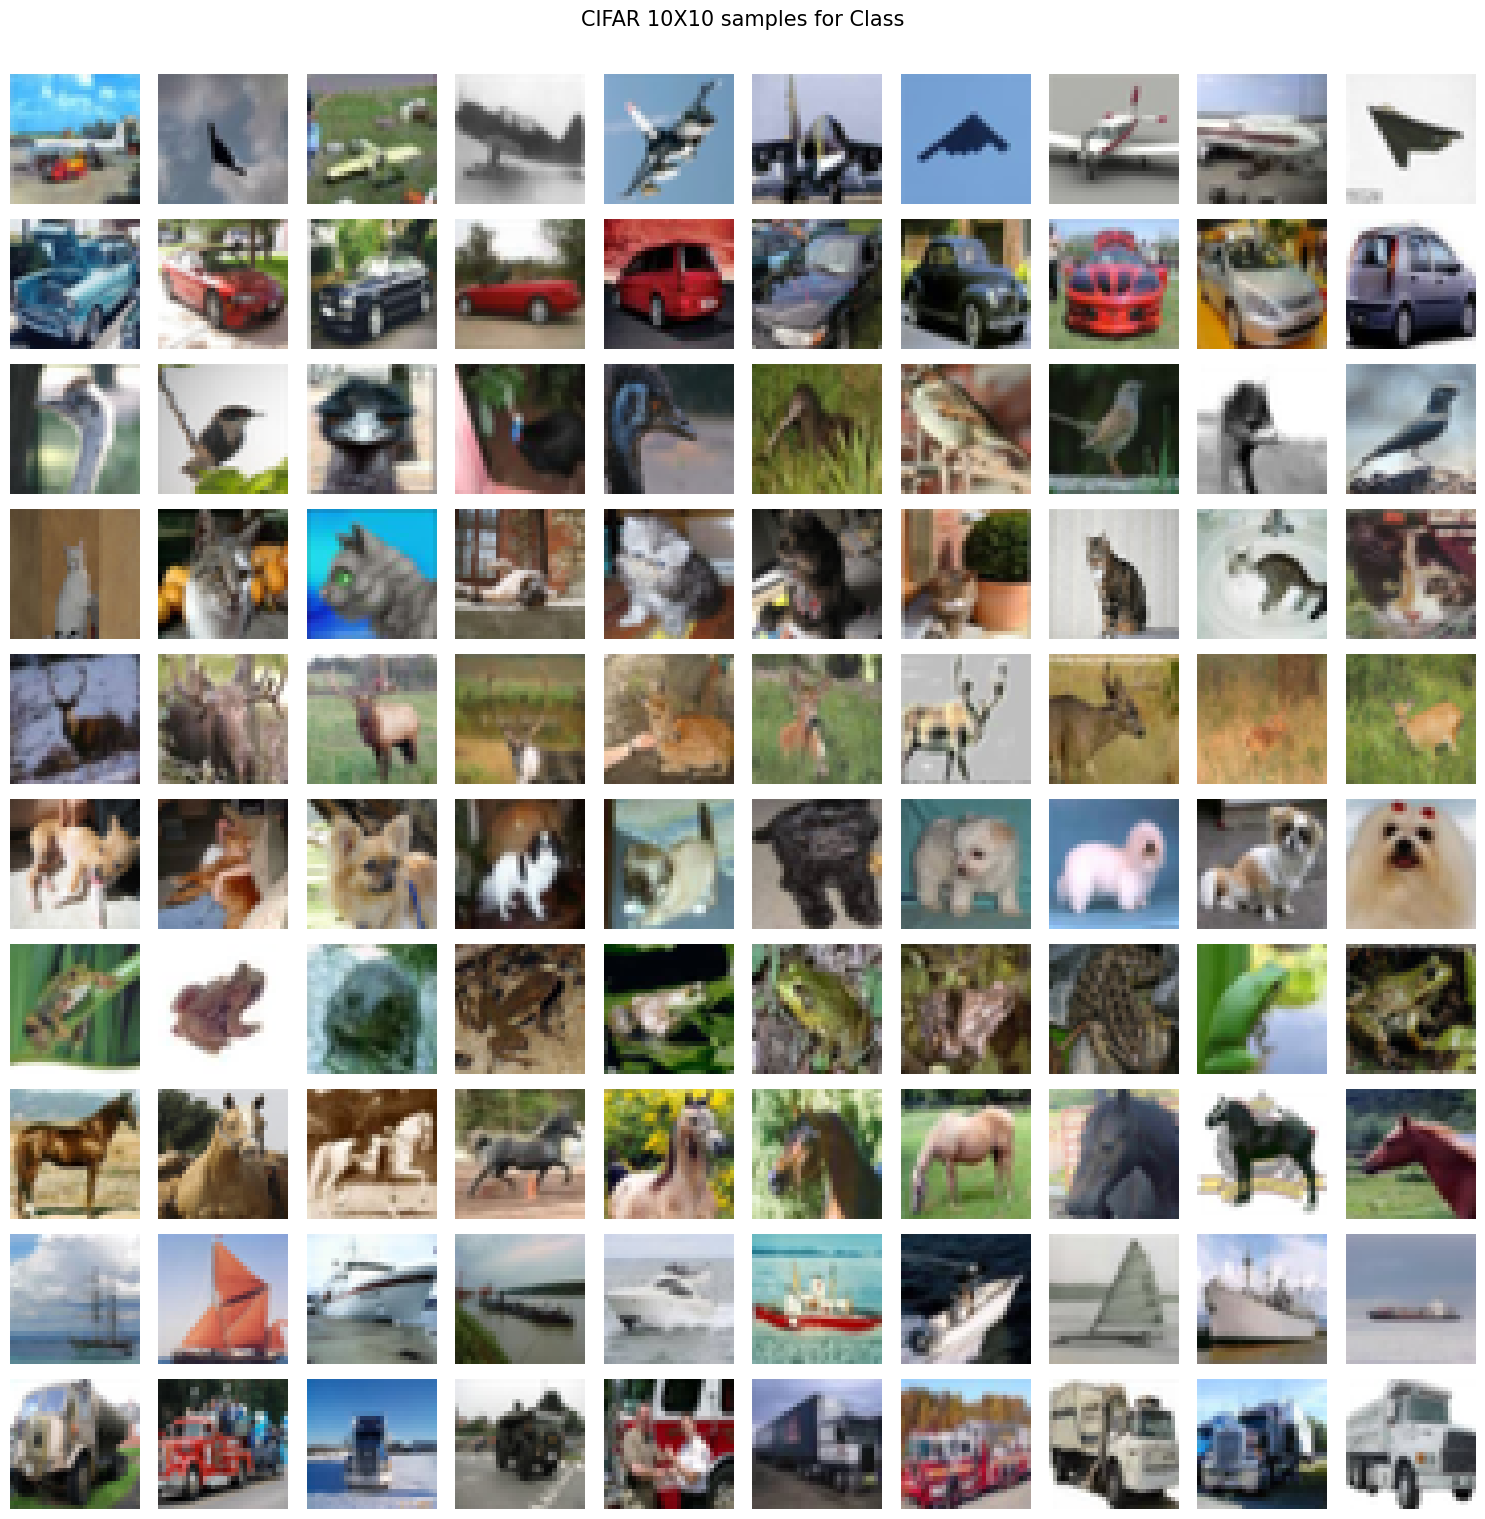

In [3]:
(input_train, label_train), (input_test, label_test) = cifar10.load_data()

class_names = ['airplane', 'automoblie', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(10,10, figsize=(15,15))
fig.suptitle('CIFAR 10X10 samples for Class', fontsize=15, y=1.01)

for class_idx in range(10):
    index=np.where(label_test.flatten()== class_idx)[0]
    samples = np.random.choice(index, 10, replace=False)
    for col, sample_idx in enumerate(samples):
        ax=axes[class_idx, col]
        ax.imshow(input_test[sample_idx])
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(class_names[class_idx], fontsize=9, rotation=0, labelpad=50, va='center')

plt.tight_layout()
plt.show()

In [4]:


input_train = input_train.astype('float32') / 255.0
input_test  = input_test.astype('float32')  / 255.0



label_train = to_categorical(label_train, NUM_CLASSES)
label_test  = to_categorical(label_test,  NUM_CLASSES)

print(f'input_train shape : {input_train.shape}')
print(f'label_train shape : {label_train.shape}')


X_train, X_val, y_train, y_val = train_test_split(
    input_train, label_train,
    test_size=0.1,
    random_state=SEED
)

print(f'X_train shape : {X_train.shape}')
print(f'X_val shape   : {X_val.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'y_val shape   : {y_val.shape}')

X_train_resized = resize(X_train, [TARGET, TARGET]).numpy()
X_val_resized   = resize(X_val,   [TARGET, TARGET]).numpy()
X_test_resized  = resize(input_test, [TARGET, TARGET]).numpy()

print(f'\nAfter resize:')
print(f'X_train shape : {X_train_resized.shape}')
print(f'X_val shape   : {X_val_resized.shape}')
print(f'X_test shape  : {X_test_resized.shape}')

input_train shape : (50000, 32, 32, 3)
label_train shape : (50000, 10)
X_train shape : (45000, 32, 32, 3)
X_val shape   : (5000, 32, 32, 3)
y_train shape : (45000, 10)
y_val shape   : (5000, 10)

After resize:
X_train shape : (45000, 96, 96, 3)
X_val shape   : (5000, 96, 96, 3)
X_test shape  : (10000, 96, 96, 3)


In [5]:

train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    rotation_range=15,
    zoom_range=0.1
)

train_generator = train_datagen.flow(
    X_train_resized, y_train,
    batch_size=BATCH_SIZE,
    seed=SEED
)


In [6]:

base_model = MobileNetV2(
    weights='imagenet',
    input_shape=(TARGET, TARGET, 3),
    include_top=False
)
base_model.trainable = False

model = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='cifar10_mobilenetv2')

model.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "cifar10_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,634 (9.90 MB)

 Trainable params: 333,578 (1.27 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

In [7]:
callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

model.fit(
    train_generator,
    validation_data=(X_val_resized, y_val),
    epochs=20,
    callbacks=callbacks_phase1
)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 159s 196ms/step - accuracy: 0.6678 - loss: 0.9913 - val_accuracy: 0.7878 - val_loss: 0.6230 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 158ms/step - accuracy: 0.7241 - loss: 0.7882 - val_accuracy: 0.8012 - val_loss: 0.5858 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 110s 156ms/step - accuracy: 0.7427 - loss: 0.7391 - val_accuracy: 0.8100 - val_loss: 0.5710 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 110s 156ms/step - accuracy: 0.7470 - loss: 0.7172 - val_accuracy: 0.8090 - val_loss: 0.5634 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.7593 - loss: 0.6928 - val_accuracy: 0.8130 - val_loss: 0.5467 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 110s 156ms/step - accuracy: 0.7626 - loss: 0.6813 - val_accuracy: 0.8152 - val_loss: 0.5441 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 110s 156ms/step - accura

In [8]:
for layer in base_model.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=1)
]

trainer = model.fit(
    train_generator,
    validation_data=(X_val_resized, y_val),
    epochs=50,
    callbacks=callbacks_phase2
)


Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 152s 185ms/step - accuracy: 0.7615 - loss: 0.7038 - val_accuracy: 0.7596 - val_loss: 0.8669 - learning_rate: 1.0000e-04
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 158ms/step - accuracy: 0.8194 - loss: 0.5234 - val_accuracy: 0.8406 - val_loss: 0.5017 - learning_rate: 1.0000e-04
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.8442 - loss: 0.4449 - val_accuracy: 0.8444 - val_loss: 0.4518 - learning_rate: 1.0000e-04
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.8636 - loss: 0.3943 - val_accuracy: 0.8694 - val_loss: 0.4044 - learning_rate: 1.0000e-04
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 158ms/step - accuracy: 0.8730 - loss: 0.3620 - val_accuracy: 0.8682 - val_loss: 0.3935 - learning_rate: 1.0000e-04
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 158ms/step - accuracy: 0.8819 - loss: 0.3378 - val_accuracy: 0.8918 - val_loss: 0.3278 - learning_rate: 1.0000e-04
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 

In [21]:
y_pred_test=model.predict(input_test)
y_pred_test=np.argmax(y_pred_test, axis=1)

print(y_pred_test[0:5])

val_loss, val_acc = model.evaluate(X_val_resized, y_val, verbose=0)
test_loss, test_acc = model.evaluate(X_test_resized, label_test, verbose=0)


train_acc = trainer.history['accuracy']
train_loss= trainer.history['loss']

print(f'\nTrain accuracy : {train_acc[-1]* 100:.2f}%')
print(f'Train loss     : {train_loss[-1]:.4f}')
print(f'\nValidation accuracy : {val_acc * 100:.2f}%')
print(f'nValidation loss     : {val_loss:.4f}')
print(f'\nTest accuracy : {test_acc * 100:.2f}%')
print(f'Test loss     : {test_loss:.4f}')

model.save('cifar10_mobilenetv2_finetuned.keras')
print('Model saved → cifar10_mobilenetv2_finetuned.keras')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
[6 0 0 1 6]

Train accuracy : 95.60%
Train loss     : 0.1306

Validation accuracy : 90.90%
nValidation loss     : 0.2978

Test accuracy : 90.21%
Test loss     : 0.3117
Model saved → cifar10_mobilenetv2_finetuned.keras


In [ ]:
print(classification_report(np.argmax(label_test, axis=1), y_pred, target_names=class_names))

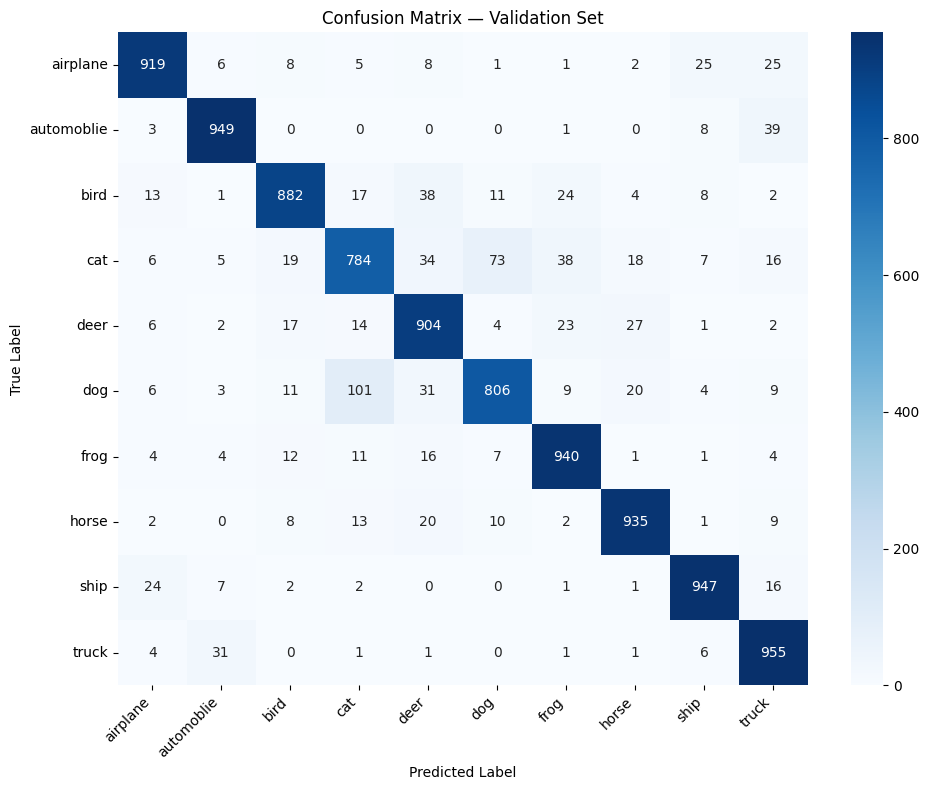

In [11]:
cm = confusion_matrix(np.argmax(label_test, axis=1), y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image

# ── Load Model ────────────────────────────────────────────────────────────────
model = tf.keras.models.load_model('cifar10_mobilenetv2_finetuned.keras')

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
TARGET = 96

# ── Inference ─────────────────────────────────────────────────────────────────
def predict(image: Image.Image) -> dict:
    img = np.array(image).astype('float32') / 255.0
    img = tf.image.resize(img, [TARGET, TARGET]).numpy()
    img = np.expand_dims(img, axis=0)

    probs = model.predict(img, verbose=0)[0]
    return {CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))}

# ── UI ────────────────────────────────────────────────────────────────────────
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type='pil', label='Upload Image'),
    outputs=gr.Label(num_top_classes=3, label='Predictions'),
    title='CIFAR-10 Classifier',
    description='Upload any image and the model will classify it into one of 10 categories: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, or truck.',
    examples=[],
    theme=gr.themes.Soft()
)

if __name__ == '__main__':
    demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9437ebb3e15ec327b8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
